In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import py3Dmol
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

from mdm2_breaker import (
    GraphSiameseNetwork_v5,
    ProteinFeaturizer,
    SmallMoleculeFeaturizer,
    SmallMoleculeFeaturizer_v5,
)

ROOT = Path(os.getcwd()).parents[0]

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb")
mol_file = os.path.join(
    ROOT, "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv"
)

In [3]:
EPOCHS = 100
LR = 1e-4

## Utility Functions

In [4]:
def view_protein(pdb_file, highlight_chain="A"):
    view = py3Dmol.view(query=pdb_file)

    # Show the whole protein as a "Cartoon" (Ribbon)
    view.setStyle({"cartoon": {"color": "spectrum"}})

    # Show the Alpha Carbons as spheres
    view.addStyle(
        {"chain": highlight_chain, "atom": "CA"},
        {"sphere": {"radius": 0.5, "color": "red"}},
    )

    view.zoomTo()
    view.show()

In [5]:
def visualize_graph(data, title="Molecule Graph"):
    # 1. Convert PyG Data to NetworkX
    # to_undirected ensures we don't draw two arrows for every bond
    G = to_networkx(data, to_undirected=True)

    # 2. Map the "Node Features" back to Element Names
    # Your allowed_atoms list from the featurizer:
    atom_map = {
        0: "C",
        1: "N",
        2: "O",
        3: "F",
        4: "S",
        5: "Cl",
        6: "Br",
        7: "I",
        8: "?",
    }

    # Create labels and colors for the plot
    labels = {}
    node_colors = []

    for node_idx in G.nodes():
        # Get the feature index from the tensor
        # data.x[node_idx] is a tensor like [0], we need the integer 0
        feat_idx = data.x[node_idx].item()

        element = atom_map.get(feat_idx, "?")
        labels[node_idx] = f"{node_idx}:{element}"  # Format: "Index:Element"

        # Color logic (CPK-ish coloring)
        if element == "C":
            node_colors.append("gray")
        elif element == "N":
            node_colors.append("blue")
        elif element == "O":
            node_colors.append("red")
        elif element == "S":
            node_colors.append("yellow")
        elif element == "Cl":
            node_colors.append("lightgreen")
        else:
            node_colors.append("orange")

    # 3. Draw it
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42)  # Force-directed layout

    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_color=node_colors,
        node_size=800,
        font_color="white",
        font_weight="bold",
        edge_color="black",
    )

    plt.title(f"{title}\npIC50: {data.y.item():.2f}")
    plt.show()

In [6]:
class SarcomaScoutSystem(pl.LightningModule):
    def __init__(
        self, model: torch.nn.Module, protein_graph: Data, lr: float = 0.00005
    ):
        """
        Args:
            model (torch.nn.Module): An instantiated Siamese Network (v1, v2, or v3).
            protein_graph (Data): The static graph of the MDM2 pocket.
            lr (float): Learning rate.
        """
        super().__init__()
        # We ignore 'model' and 'protein_graph' in hparams to avoid pickling large objects
        # into the checkpoint header unnecessarily.
        self.save_hyperparameters(ignore=["model", "protein_graph"])

        # 1. Dependency Injection: We store whatever model you passed in.
        self.model = model

        self.lr = lr

        # 2. Store the Protein Graph as a "Buffer"
        # This keeps the static graph on the correct GPU without being a trainable parameter.
        self.register_buffer("protein_x", protein_graph.x)
        self.register_buffer("protein_edge_index", protein_graph.edge_index)

        # Create a dummy batch vector [0, 0, 0...] for the single protein
        batch_vec = torch.zeros(protein_graph.x.size(0), dtype=torch.long)
        self.register_buffer("protein_batch", batch_vec)

    def get_protein_graph(self):
        """Reconstructs the Data object from the GPU buffers."""
        return Data(
            x=self.protein_x,
            edge_index=self.protein_edge_index,
            batch=self.protein_batch,
        )

    def forward(self, protein_data, molecule_data):
        return self.model(protein_data, molecule_data)

    def training_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch

        # Predicting
        preds = self(protein_data, molecule_data)

        # Squeeze to align shapes: [Batch, 1] -> [Batch]
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)

        self.log("train_loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch
        preds = self(protein_data, molecule_data)
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log("val_loss", loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [7]:
def define_trainer(
    epochs=100, lr=1e-4, save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}"
):
    # Checkpoint: Save the model with the lowest Validation Loss
    checkpoint_cb = ModelCheckpoint(
        dirpath="checkpoints/",
        filename=save_name,
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    # Early Stopping: Stop if val_loss doesn't improve for 10 epochs
    early_stop_cb = EarlyStopping(monitor="val_loss", patience=10, mode="min")

    lr_monitor = LearningRateMonitor(logging_interval="epoch")

    trainer = pl.Trainer(
        max_epochs=epochs,
        accelerator="cpu",
        devices=1,
        callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
        log_every_n_steps=10,
    )

    return trainer


def generate_loaders(
    data_class,
    train_indices,
    val_indices,
    test_indices,
    batch_size=64,
    mol_file=mol_file,
):
    data = data_class(
        root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
    )

    train_dataset = data[train_indices]
    val_dataset = data[val_indices]
    test_dataset = data[test_indices]

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=7,
        persistent_workers=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=7,
        persistent_workers=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=7,
        persistent_workers=True,
    )

    return train_loader, val_loader, test_loader


def train_model(
    model,
    mol_class,
    protein_graph,
    train_indices,
    val_indices,
    test_indices,
    epochs=100,
    lr=1e-4,
    save_name="sarcoma-model-{epoch:02d}-{val_loss:.2f}",
):
    trainer = define_trainer(epochs=epochs, lr=lr, save_name=save_name)

    train_loader, val_loader, test_loader = generate_loaders(
        mol_class, train_indices, val_indices, test_indices
    )

    system = SarcomaScoutSystem(model=model, protein_graph=protein_graph, lr=lr)

    # trainer.fit(system, train_loader, val_loader)

    return model, train_loader, val_loader, test_loader

In [8]:
def get_metrics(model, data_loader, protein_graph):
    y_pred = []
    y_true = []

    # 1. Collect Data
    with torch.no_grad():  # Good practice to disable gradients here
        for x in data_loader:
            # Predict
            out = model(protein_graph, x).detach().cpu().numpy()
            y_pred.append(out)
            y_true.append(x.y.detach().cpu().numpy())

    # 2. Concatenate and FLATTEN (The Fix)
    y_pred = np.concatenate(y_pred).ravel()  # Force 1D array
    y_true = np.concatenate(y_true).ravel()  # Force 1D array

    # 3. Calculate Correct MSE
    mse = np.mean((y_pred - y_true) ** 2)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

    return mse, r2, y_pred, y_true


def plot_predictions(model, loaders, protein_graph, title):
    _, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for idx, loader in enumerate(loaders):
        mse, r2, y_pred, y_true = get_metrics(model, loader, protein_graph)

        ax[idx].scatter(y_pred, y_true, alpha=0.5)

        # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
        m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax[idx].plot([m_min, m_max], [m_min, m_max], "k--", label="Perfect Fit")
        ax[idx].set_aspect("equal", "box")
        if idx == 1:
            ax[idx].set_xlabel("Predicted pIC50")
        if idx == 0:
            ax[idx].set_ylabel("True pIC50")
        ax[idx].set_title(f"MSE: {mse:.4f} | R2: {r2:.4f}")
        ax[idx].legend()
        ax[idx].grid(True, alpha=0.3)
    plt.suptitle(title)
    plt.show()


def plot_xgboost_predictions(
    pred_train_mse_tuple, pred_val_mse_tuple, pred_test_mse_tuple
):
    _, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for idx, (y_pred, y_true, mse) in enumerate(
        [pred_train_mse_tuple, pred_val_mse_tuple, pred_test_mse_tuple]
    ):
        ax[idx].scatter(y_pred, y_true, alpha=0.5)

        # Add a DIAGONAL line (Perfect Prediction) - Much more useful than the mean line
        m_min, m_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax[idx].plot([m_min, m_max], [m_min, m_max], "k--", label="Perfect Fit")
        r2 = 1 - (
            np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
        )

        if idx == 1:
            ax[idx].set_xlabel("Predicted pIC50")
        if idx == 0:
            ax[idx].set_ylabel("True pIC50")
        ax[idx].set_title(f"MSE: {mse:.4f} | R2: {r2:.4f}")
        ax[idx].legend()
        ax[idx].grid(True, alpha=0.3)

    plt.suptitle("XGBoost Predictions")
    plt.show()


In [9]:
def load_model_from_checkpoint(model_class, checkpoint_path):
    # 1. Load the raw checkpoint
    checkpoint = torch.load(checkpoint_path)
    state_dict = checkpoint["state_dict"]

    # 2. Fix the keys (Remove "model." prefix)
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith("model."):
            # Strip the first 6 characters ("model.")
            new_key = key[6:]
            new_state_dict[new_key] = value

    # 3. Initialize your raw model
    model = model_class()

    # 4. Load the cleaned weights
    model.load_state_dict(new_state_dict)
    model.eval()

    return model

In [10]:
def plot_loss(csv_path):
    df = pd.read_csv(csv_path)
    fix, ax = plt.subplots(figsize=(10, 5))

    df.plot(
        x="step",
        y="train_loss",
        title="Training Loss",
        ax=ax,
        label="Training Loss",
        color="blue",
        legend=True,
        style="-",
    )
    df.dropna(subset=["val_loss"]).plot(
        x="step",
        y="val_loss",
        title="Validation Loss",
        ax=ax,
        label="Validation Loss",
        color="red",
        legend=True,
        style="-o",
    )
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.set_title("Training and Validation Loss")
    ax.legend()
    plt.show()


In [11]:
def plot_xgb_loss(xgb_model):
    # 4. Extract Results
    results = xgb_model.evals_result()
    epochs = len(results["validation_0"]["rmse"])
    x_axis = range(0, epochs)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_axis, results["validation_0"]["rmse"], label="Train")
    ax.plot(x_axis, results["validation_1"]["rmse"], label="Validation")
    ax.plot(x_axis, results["validation_2"]["rmse"], label="Test")
    ax.legend()
    plt.ylabel("RMSE")
    plt.xlabel("n_estimators")
    plt.title("XGBoost Loss vs. n_estimators")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Best Iteration: {xgb_model.best_iteration}")
    print(f"Best Score (Validation MSE): {xgb_model.best_score:.4f}")


## Load Protein Data

In [12]:
protein_data = ProteinFeaturizer(pdb_file=pdb_file)
view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Load Small Molecule Data

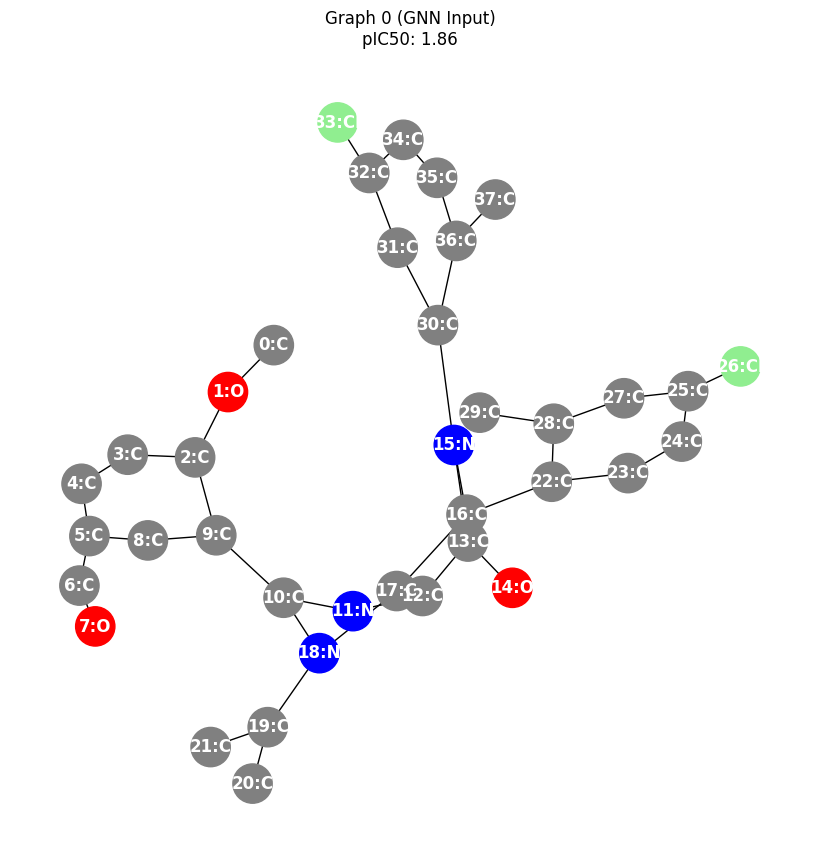

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152


In [13]:
mol_data = SmallMoleculeFeaturizer(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)
df_mol = pd.read_csv(mol_data.processed_paths[0].replace(".pt", ".csv"))

visualize_graph(mol_data[0], title="Graph 0 (GNN Input)")
df_mol.head(3)

## Prepare Data for Modeling

### Split Data into Train/Test/Val

In [14]:
torch.manual_seed(42)  # Fixed seed for reproducibility
num_samples = len(mol_data)
indices = torch.randperm(num_samples).tolist()

train_size = int(0.8 * num_samples)
val_size = int(0.1 * num_samples)
test_size = num_samples - train_size - val_size

# Slice the Indices
train_indices = indices[:train_size]
val_indices = indices[train_size : train_size + val_size]
test_indices = indices[train_size + val_size :]

# Get the Protein Graph (from your ProteinFeaturizer)
protein_graph = protein_data.get_graph()

/Users/dantrainer/projects/cancer_research/src/mdm2_breaker/featurizers.py:92: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


## Modeling

### Graph Network v3 - GATv2Conv Layers. Add Bond Attributes. Add Atom Features.

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


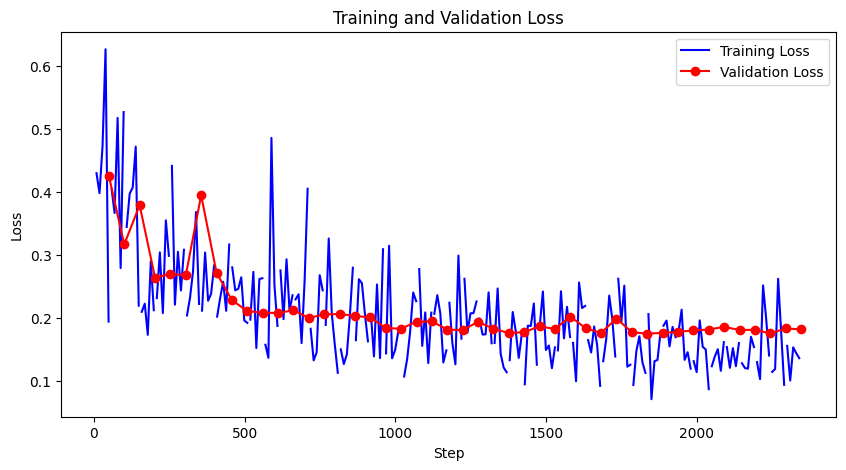

In [15]:
model_v5, train_loader_v5, val_loader_v5, test_loader_v5 = train_model(
    model=GraphSiameseNetwork_v5(),
    mol_class=SmallMoleculeFeaturizer_v5,
    protein_graph=protein_graph,
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices,
    epochs=EPOCHS,
    lr=LR,
    save_name="Model-v5-updated",
)
plot_loss("lightning_logs/version_5/metrics.csv")

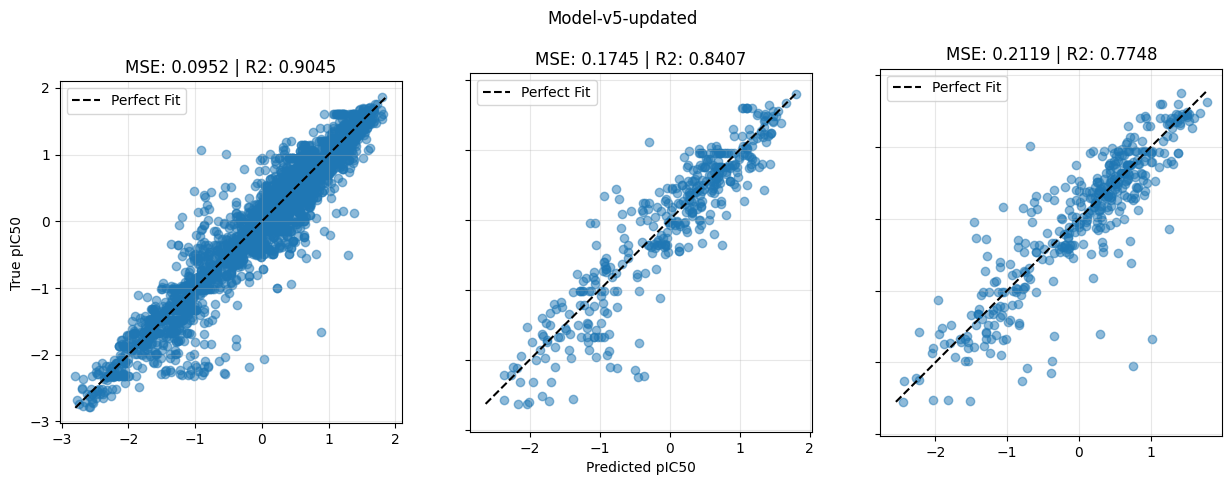

In [16]:
model_v5 = load_model_from_checkpoint(
    GraphSiameseNetwork_v5, "checkpoints/Model-v5-updated.ckpt"
)
plot_predictions(
    model_v5,
    (train_loader_v5, val_loader_v5, test_loader_v5),
    protein_graph,
    "Model-v5-updated",
)

In [17]:
dataset_v5 = SmallMoleculeFeaturizer_v5(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)
dataset_v5.df.head(3)

,SMILES,IC50,Target,Organism,IC50_numeric,pIC50,pIC50_norm
0,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,0.04,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.040,10.397940,1.862604
1,COc1ccc(cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1ccc(...,0.05,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.050,10.301030,1.799189
2,COC[C@@H](C)n1c(nc2C(=O)N([C@H](c12)c1ccc(Cl)c...,0.059,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.059,10.229148,1.752152


3378


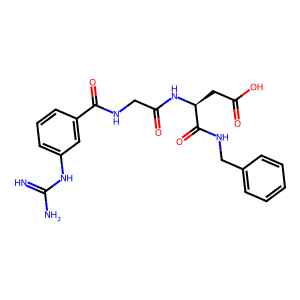

SMILES          NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C...
IC50                                                        >1000
Target                           E3 ubiquitin-protein ligase Mdm2
Organism                                             Homo sapiens
IC50_numeric                                               1000.0
pIC50                                                         6.0
pIC50_norm                                              -1.015267
Name: 3378, dtype: object

In [18]:
target_pic = 6

idx = np.argmin(np.abs(dataset_v5.df['pIC50'] - target_pic))
print(idx)

mol = Chem.MolFromSmiles(dataset_v5.df.iloc[idx]['SMILES'])
img = Draw.MolToImage(
    mol,
)
display(img)

dataset_v5.df.iloc[idx]

In [19]:
dataset_v5.df.iloc[idx]

SMILES          NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C...
IC50                                                        >1000
Target                           E3 ubiquitin-protein ligase Mdm2
Organism                                             Homo sapiens
IC50_numeric                                               1000.0
pIC50                                                         6.0
pIC50_norm                                              -1.015267
Name: 3378, dtype: object

In [20]:
from torch_geometric.nn import (
    global_add_pool,
    global_max_pool,
)

def calculate_design_gradients(model, data):

    # 1. PREPARE INPUTS
    # We need the protein data because the model expects it (Siamese)
    model.eval()
    model.zero_grad() # Clear previous gradients

    # 2. THE TRICK: Manually run the Atom Encoder first
    # This converts discrete integers -> continuous embeddings
    x_indices = data.x[:, :3].long()
    x_floats = data.x[:, 3:].float()

    # Run encoder, DETACH from graph, and RE-ENABLE gradients
    # This makes 'x_embed' the "Leaf Node" for the backward pass
    x_embed = model.atom_encoder(x_indices, x_floats).detach()
    x_embed.requires_grad = True 

    node_embeddings = model.molecule_encoder(x_embed, data.edge_index, data.edge_attr)

    # We need to tell PyTorch that all these 39 atoms belong to "Graph 0"
    batch = torch.zeros(node_embeddings.shape[0], dtype=torch.long, device=node_embeddings.device)

    # Pool them into a single Graph Vector
    v_sum = global_add_pool(node_embeddings, batch) # Shape: [1, 128]
    v_max = global_max_pool(node_embeddings, batch) # Shape: [1, 128]
    mol_vec = torch.cat([v_sum, v_max], dim=1)      # Shape: [1, 256]

    # B. Run Protein GNN
    with torch.no_grad():
        prot_vec = model.encode_protein(protein_graph) # Shape: [1, 256]

    # C. Prepare Expert Features
    expert_features = data.expert_features.squeeze(1) # Shape: [1, 2052]

    # DEBUG: Now they should all be 1 in the first dimension
    print(f"Shapes: Prot {prot_vec.shape}, Mol {mol_vec.shape}, Exp {expert_features.shape}")

    # D. Predictor
    combined = torch.cat([prot_vec, mol_vec, expert_features], dim=1)
    prediction = model.mlp(combined)

    print(f"Current Predicted pIC50: {prediction.item():.2f}")

    # 4. BACKWARD PASS
    loss = -prediction 
    loss.backward()

    # 5. EXTRACT GRADIENTS
    grads = x_embed.grad.norm(dim=1).cpu().numpy()
    print(grads.shape)
    print(grads)
    return grads

# # --- RUN IT ---
grads = calculate_design_gradients(model_v5, data = dataset_v5[idx])

Shapes: Prot torch.Size([1, 256]), Mol torch.Size([1, 256]), Exp torch.Size([1, 2052])
Current Predicted pIC50: -0.52
(39,)
[0.11916644 0.20607951 0.10395253 0.19799921 0.4117196  0.42521518
 0.4734667  0.41193154 0.45364738 0.37931192 0.32470757 0.16749415
 0.27021733 0.29909158 0.32705426 0.16278896 0.31607413 0.39490658
 0.31723326 0.3119213  0.19347513 0.17502959 0.3158358  0.16191843
 0.25084707 0.31866878 0.5281055  0.4590745  0.3751127  0.362892
 0.37878865 0.362892   0.3751127  0.4590745  0.3751127  0.362892
 0.37878865 0.362892   0.3751127 ]


SMILES: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C(=O)NCc1ccccc1
Max Gradient: 0.5281


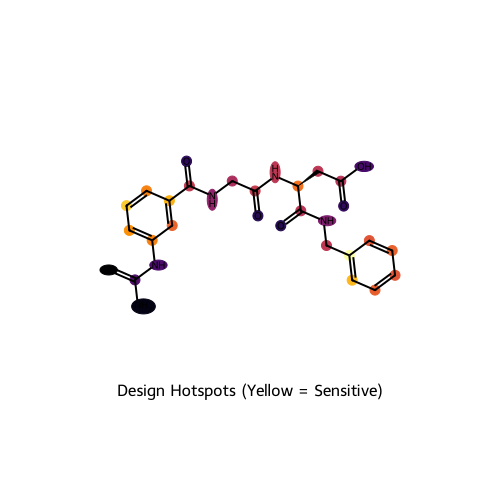

In [21]:
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image

def visualize_gradient_hotspots(smiles, grads):
    # 1. Get Molecule
    mol = Chem.MolFromSmiles(smiles)
    # mol = Chem.AddHs(mol) # Match the GNN graph size (39 atoms)

    # 2. Safety Check: Index Alignment
    if mol.GetNumAtoms() != len(grads):
        print(f"Warning: Molecule has {mol.GetNumAtoms()} atoms but Gradients have {len(grads)}.")
        # Crop gradients to match if necessary to prevent crashing
        grads = grads[:mol.GetNumAtoms()]

    # 3. Normalize Gradients
    min_g, max_g = grads.min(), grads.max()
    range_g = max_g - min_g + 1e-9

    cmap = plt.get_cmap('inferno') # Yellow = Hot

    highlight_atoms = []
    highlight_colors = {}

    print(f"SMILES: {smiles}")
    print(f"Max Gradient: {max_g:.4f}")

    for aidx, g_score in enumerate(grads):
        norm_score = (g_score - min_g) / range_g
            
        highlight_atoms.append(aidx)
        
        # Get Color from Map
        rgba = cmap(norm_score)
        
        # --- THE FIX: Force conversion to Python floats ---
        # RDKit ignores numpy.float64, causing the "All Salmon" bug.
        color = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
        highlight_colors[aidx] = color
        
    # 4. High-Res Drawing with MolDraw2D
    d = rdMolDraw2D.MolDraw2DCairo(500, 500)
    d.drawOptions().useBWAtomPalette()
    d.drawOptions().padding = 0.2

    # Draw nicely
    d.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_colors,
        highlightBonds=[],
        legend=f"Design Hotspots (Yellow = Sensitive)"
    )
    d.FinishDrawing()
    
    return d

# # --- RUN IT ---
# # We use the 'grads' array you just calculated in the previous step
d = visualize_gradient_hotspots(smiles = dataset_v5.df.iloc[idx]['SMILES'], grads=grads)
display(Image(d.GetDrawingText()))

In [25]:
def check_mutation_impact(model, dataset, mutant_smiles):
    # 1. One line to convert SMILES -> Tensor
    # This guarantees the features match training EXACTLY
    new_data = dataset.featurize_smiles(mutant_smiles)
    
    # 2. Score it
    model.eval()
    
    with torch.no_grad():
        # Pass to device if needed: new_data.to(model.device)
        pred = model(protein_graph, new_data).item()
        
    return pred

In [31]:
from rdkit.Chem import AllChem

def test_benzylic_methylation_fixed(model, dataset, idx):
    # 1. Get Molecule
    smiles = dataset.df.iloc[idx]['SMILES']
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) # Explicit Hs are needed so we can find one to replace
    
    # 2. Identify Target (Benzylic Carbon)
    target_c_idx = -1
    target_h_idx = -1
    
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == 'C' and not atom.GetIsAromatic():
            # Check neighbors for an Aromatic Ring
            is_benzylic = False
            h_neighbor = -1
            
            for nbr in atom.GetNeighbors():
                if nbr.GetIsAromatic():
                    is_benzylic = True
                if nbr.GetSymbol() == 'H':
                    h_neighbor = nbr.GetIdx()
            
            # We need BOTH a ring connection AND a sacrificial Hydrogen
            if is_benzylic and h_neighbor != -1:
                target_c_idx = atom.GetIdx()
                target_h_idx = h_neighbor
                print(f"Found Benzylic Carbon: {target_c_idx}")
                print(f"Found Sacrificial Hydrogen: {target_h_idx}")
                break
    
    if target_h_idx == -1:
        print("Error: No suitable Benzylic Carbon with a Hydrogen found.")
        return

    # 3. Perform Mutation (Replace H with C)
    print(f"Mutating: Replacing Hydrogen {target_h_idx} with Methyl Group...")
    
    rw_mol = Chem.RWMol(mol)
    
    # Overwrite the Hydrogen atom with a Carbon atom
    # This keeps the bond to the parent carbon intact!
    # H-C  -->  C-C (Methyl)
    rw_mol.ReplaceAtom(target_h_idx, Chem.Atom(6))
    
    # 4. Clean Up
    try:
        # Sanitize calculates new valencies and adds implicit hydrogens to the new methyl
        Chem.SanitizeMol(rw_mol)
        new_smiles = Chem.MolToSmiles(rw_mol)
        print(f"\nOriginal: {smiles}")
        print(f"Mutant:   {new_smiles}")
        
        # 5. OPTIONAL: Visualize the change
        # display(Draw.MolToImage(rw_mol, size=(300,300), legend="Mutated Molecule"))
        
    except Exception as e:
        print(f"Mutation Failed: {e}")

    return new_smiles, smiles
# Run the Fixed Mutation
new_smiles, original_smiles = test_benzylic_methylation_fixed(model_v5, dataset_v5, idx=idx)

Found Benzylic Carbon: 25
Found Sacrificial Hydrogen: 50
Mutating: Replacing Hydrogen 50 with Methyl Group...

Original: NC(=N)Nc1cccc(c1)C(=O)NCC(=O)N[C@@H](CC(O)=O)C(=O)NCc1ccccc1
Mutant:   [H]N=C(N([H])[H])N([H])c1c([H])c([H])c([H])c(C(=O)N([H])C([H])([H])C(=O)N([H])[C@]([H])(C(=O)N([H])C([H])(C)c2c([H])c([H])c([H])c([H])c2[H])C([H])([H])C(=O)O[H])c1[H]


In [27]:
check_mutation_impact(model_v5, dataset_v5, original_smiles)

-0.7737098932266235

In [26]:
check_mutation_impact(model_v5, dataset_v5, new_smiles)

-0.7546812295913696

Shapes: Prot torch.Size([1, 256]), Mol torch.Size([1, 256]), Exp torch.Size([1, 2052])
Current Predicted pIC50: -0.75
(33,)
[0.15630451 0.29934928 0.17434143 0.20144066 0.23679824 0.20961575
 0.23309751 0.21565649 0.26927146 0.20566344 0.1121517  0.18771787
 0.21602279 0.24070615 0.12416963 0.24889784 0.4233918  0.34625143
 0.17686851 0.30396935 0.3663466  0.19574289 0.3921375  0.33723262
 0.35116723 0.36869738 0.35116723 0.33723262 0.30367413 0.27187708
 0.13893512 0.17554305 0.24981885]
SMILES: [H]N=C(N([H])[H])N([H])c1c([H])c([H])c([H])c(C(=O)N([H])C([H])([H])C(=O)N([H])[C@]([H])(C(=O)N([H])C([H])(C)c2c([H])c([H])c([H])c([H])c2[H])C([H])([H])C(=O)O[H])c1[H]
Max Gradient: 0.4234


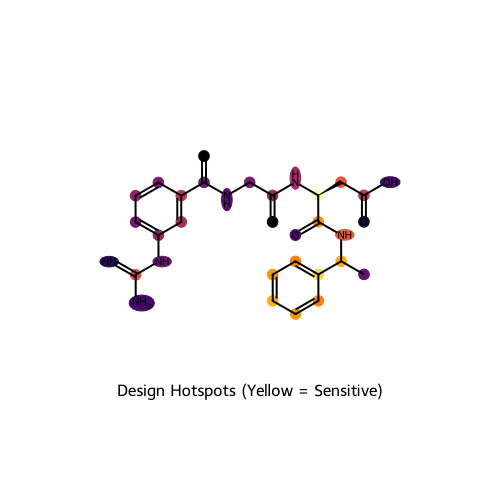

In [30]:
new_data = dataset_v5.featurize_smiles(new_smiles)

grads = calculate_design_gradients(model_v5, data = new_data)
d = visualize_gradient_hotspots(smiles = new_smiles, grads=grads)
display(Image(d.GetDrawingText()))

In [ ]:
mol_data = SmallMoleculeFeaturizer_v5(
    root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
)

In [ ]:
mol_data.y

tensor([ 1.8626,  1.7992,  1.7522,  ..., -1.9519, -1.9519, -1.9571])

In [ ]:
def inspect_attention_raw_values(model, dataset, idx=10):
    data = dataset[idx]
    model.eval()

    with torch.no_grad():
        # Get weights from Layer 1 (Chemistry Layer)
        # Ensure you are calling your modified method that returns (x, (edge_index, alpha))
        _, (edge_index, alpha) = model.molecule_encoder.conv1(
            model.atom_encoder(data.x[:, :3].long(), data.x[:, 3:].float()),
            data.edge_index,
            data.edge_attr,
            return_attention_weights=True,
        )

    # alpha shape is [Num_Edges, Num_Heads]
    print("--- Raw Attention Stats (Layer 1) ---")
    print(f"Shape: {alpha.shape}")

    for head in range(alpha.shape[1]):
        head_vals = alpha[:, head].cpu().numpy()
        print(f"\nHead {head}:")
        print(f"  Min: {head_vals.min():.4f}")
        print(f"  Max: {head_vals.max():.4f}")
        print(f"  Mean: {head_vals.mean():.4f}")
        print(f"  Std Dev: {head_vals.std():.4f}")

        # Check for "GCN Collapse" (Uniform weights)
        if head_vals.std() < 1e-4:
            print(
                "  [WARNING] Low variance! This head is acting like a simple GCN (Average)."
            )
        else:
            print("  [OK] High variance. This head is making choices.")


inspect_attention_raw_values(
    model_v3,
    SmallMoleculeFeaturizer_v3(
        root=os.path.join(ROOT, "data", "MDM2_Breaker"), file_path=mol_file
    ),
)


NameError: name 'model_v3' is not defined